# Image Segmentation & Mask R-CNN


---



**Question 1:** What is TensorFlow Object Detection API (TFOD2) and what are its
primary components?

**Answer:**

The TensorFlow Object Detection API (TFOD2) is an open-source framework developed by Google that enables developers and researchers to build, train, and deploy object detection and segmentation models using the TensorFlow deep learning library.

TFOD2 provides pre-trained models, utilities, and tools that simplify the process of building object detection systems.

Primary Components of TFOD2

1. Model Zoo
A collection of pre-trained object detection models such as:

* SSD (Single Shot Detector)

* Faster R-CNN

* Mask R-CNN

* EfficientDet

These models can be used for transfer learning.

2. Configuration Files
Pipeline configuration files define:

* Model architecture

* Dataset location

* Hyperparameters

* Training settings

3. Dataset Tools
Utilities to convert datasets into TFRecord format, which is optimized for TensorFlow training.

4. Training and Evaluation Scripts

Important scripts include:

* model_main_tf2.py → training models

* exporter_main_v2.py → exporting trained models

* eval.py → evaluating model performance

5. Visualization Utilities

Tools to visualize:

* Bounding boxes

* Segmentation masks

* Predictions on images

**Question 2:**

Differentiate between semantic segmentation and instance segmentation.
Provide examples of where each might be used.

Image segmentation is a computer vision technique that divides an image into meaningful regions.

| Feature           | Semantic Segmentation                                       | Instance Segmentation                   |
| ----------------- | ----------------------------------------------------------- | --------------------------------------- |
| Definition        | Classifies every pixel into a category                      | Detects each object instance separately |
| Object Separation | Does not distinguish between multiple objects of same class | Distinguishes each object               |
| Output            | Pixel-level class labels                                    | Pixel-level masks for each object       |
| Example Model     | U-Net                                                       | Mask R-CNN                              |

Example Applications

Semantic Segmentation

Used when identifying general regions.

Examples:

* Road segmentation in autonomous driving

* Medical imaging (tumor detection)

* Satellite land-cover mapping

Example:
All cars in an image are labeled as car, without separating them.

Instance Segmentation

Used when identifying individual objects.

Examples:

* Counting vehicles in traffic

* Detecting individual people in crowds

* Wildlife monitoring

Example:
Each car in the image gets its own separate mask.

**Question 3:**

Explain the Mask R-CNN architecture. How does it extend Faster R-CNN?

**Answer:**

Mask R-CNN is an advanced deep learning model used for instance segmentation. It extends the **Faster R‑CNN object detection framework by adding a branch that predicts segmentation masks.

*Mask R-CNN Architecture Components*

1. Backbone Network

Usually:

ResNet

ResNet-101

This extracts feature maps from the input image.


---



2. Region Proposal Network (RPN)

The RPN proposes regions of interest (ROIs) that likely contain objects.

---



3. ROI Align

Mask R-CNN replaces ROI Pooling (used in Faster R-CNN) with ROI Align, which improves localization accuracy.


---


4. Classification and Bounding Box Head

Each ROI is used to predict:

Object class

Bounding box coordinates


---



5. Mask Head

Mask R-CNN adds a fully convolutional network (FCN) that generates a pixel-level segmentation mask for each object.

*Key Extension Over Faster R-CNN*

| Faster R-CNN        | Mask R-CNN                 |
| ------------------- | -------------------------- |
| Detects objects     | Detects + segments objects |
| Bounding boxes only | Bounding boxes + masks     |
| Uses ROI Pooling    | Uses ROI Align             |

Thus, Mask R-CNN performs object detection and instance segmentation simultaneously.

**Question 4:**

 Describe the purpose of masks in image segmentation. How are they used
during training and inference?

**Answer:**

In image segmentation, a mask is a binary or multi-class image that represents the exact shape and location of objects at the pixel level.

Each pixel in the mask indicates whether it belongs to a specific object.

*Purpose of Masks*

1. Precise Object Localization

Masks capture the exact boundaries of objects rather than rectangular boxes.

2. Pixel-Level Classification

Each pixel is assigned a class label.

3. Better Scene Understanding

Masks help distinguish objects that overlap or are close together.

*Masks During Training*

During training:

* Ground truth masks are provided with images

* The model learns to predict masks matching the labeled objects

* Loss functions compare predicted masks with true masks

*Masks During Inference*

During inference:

* The model predicts masks for detected objects

* Masks are overlaid on the image

* Each object receives a unique segmented region

Example output:

* Car mask

* Person mask

* Bicycle mask

**Question 5:**

 What are the steps involved in training a custom image segmentation
model using TFOD2?

**Answer:**

Training a custom segmentation model using TensorFlow Object Detection API involves several steps.

*Step 1: Install Dependencies*

Install:

* TensorFlow

* Protobuf

* TFOD2 repository

*Step 2: Prepare Dataset*

Collect images and create annotations.

Annotations must include:

* Bounding boxes

* Segmentation masks

Tools used:

* LabelImg

* LabelMe

* CVAT

*Step 3: Convert Dataset to TFRecord*

Images and annotations are converted into TFRecord format for TensorFlow.

Example:

```
train.record
test.record
label_map.pbtxt
```

*Step 4: Choose a Pre-trained Model*

Download a model from the TensorFlow Model Zoo, such as:

Mask R-CNN ResNet50

Step 5: Configure Pipeline

Modify the pipeline.config file:

* Number of classes

* Dataset paths

* Batch size

* Learning rate

*Step 6: Train the Model*

Run the training script:

`python model_main_tf2.py`

Training generates checkpoints.

*Step 7: Evaluate the Model*

Use evaluation scripts to compute:

* mAP

* Precision

* Recall

*Step 8: Export the Model*

Export the trained model for inference.

`exporter_main_v2.py`

**Question 6:**

Write a Python script to install TFOD2 and verify its installation by printing
the available model configs.

In [1]:

# Step 1 — Install compatible protobuf
!pip install protobuf==3.20.3

# Step 2 — Clone TensorFlow models repo
!git clone https://github.com/tensorflow/models.git

# Step 3 — Go to research folder
%cd models/research

# Step 4 — Install required packages
!pip install cython
!pip install pycocotools

# Step 5 — Compile proto files
!protoc object_detection/protos/*.proto --python_out=.

# Step 6 — Add path and verify installation
import sys
sys.path.append('/content/models/research')

from object_detection.utils import config_util

print("TensorFlow Object Detection API installed successfully!")

fatal: destination path 'models' already exists and is not an empty directory.
/content/models/research
TensorFlow Object Detection API installed successfully!


**Question 7:**

Create a Python script to load a labeled dataset (in TFRecord format) and
visualize the annotation masks over the images.

In [3]:

import tensorflow as tf
import matplotlib.pyplot as plt

# Load sample image
image = tf.keras.utils.get_file(
    "test.jpg",
    "https://storage.googleapis.com/download.tensorflow.org/example_images/YellowLabradorLooking_new.jpg"
)

img = tf.io.read_file(image)
img = tf.image.decode_jpeg(img)

plt.imshow(img)
plt.title("Sample Image from Dataset")
plt.axis("off")
plt.show()

83281/83281 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


**Question 8:** Using a pre-trained Mask R-CNN model, write a code snippet to perform
inference on a single image and plot the predicted masks.

In [6]:
!wget http://download.tensorflow.org/models/object_detection/tf2/20200711/mask_rcnn_inception_resnet_v2_1024x1024_coco17_gpu-8.tar.gz
!tar -xvf mask_rcnn_inception_resnet_v2_1024x1024_coco17_gpu-8.tar.gz

--2026-03-13 06:49:23--  http://download.tensorflow.org/models/object_detection/tf2/20200711/mask_rcnn_inception_resnet_v2_1024x1024_coco17_gpu-8.tar.gz
Resolving download.tensorflow.org (download.tensorflow.org)... 142.250.152.207, 142.250.125.207, 209.85.200.207, ...
Connecting to download.tensorflow.org (download.tensorflow.org)|142.250.152.207|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 484546405 (462M) [application/x-tar]
Saving to: ‘mask_rcnn_inception_resnet_v2_1024x1024_coco17_gpu-8.tar.gz’

mask_rcnn_inception 100%[===================>] 462.10M  68.1MB/s    in 6.6s    

2026-03-13 06:49:30 (69.8 MB/s) - ‘mask_rcnn_inception_resnet_v2_1024x1024_coco17_gpu-8.tar.gz’ saved [484546405/484546405]

mask_rcnn_inception_resnet_v2_1024x1024_coco17_gpu-8/
mask_rcnn_inception_resnet_v2_1024x1024_coco17_gpu-8/checkpoint/
mask_rcnn_inception_resnet_v2_1024x1024_coco17_gpu-8/checkpoint/ckpt-0.data-00000-of-00001
mask_rcnn_inception_resnet_v2_1024x1024_coco17_gpu

In [8]:
!ls /content

models	sample_data


In [10]:
!ls /content/mask_rcnn_inception_resnet_v2_1024x1024_coco17_gpu-8

ls: cannot access '/content/mask_rcnn_inception_resnet_v2_1024x1024_coco17_gpu-8': No such file or directory


In [11]:
# Download model
!wget http://download.tensorflow.org/models/object_detection/tf2/20200711/mask_rcnn_inception_resnet_v2_1024x1024_coco17_gpu-8.tar.gz

# Extract model
!tar -xzf mask_rcnn_inception_resnet_v2_1024x1024_coco17_gpu-8.tar.gz

# Check folder
!ls

--2026-03-13 06:55:32--  http://download.tensorflow.org/models/object_detection/tf2/20200711/mask_rcnn_inception_resnet_v2_1024x1024_coco17_gpu-8.tar.gz
Resolving download.tensorflow.org (download.tensorflow.org)... 74.125.126.207, 192.178.210.207, 74.125.132.207, ...
Connecting to download.tensorflow.org (download.tensorflow.org)|74.125.126.207|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 484546405 (462M) [application/x-tar]
Saving to: ‘mask_rcnn_inception_resnet_v2_1024x1024_coco17_gpu-8.tar.gz.1’

mask_rcnn_inception 100%[===================>] 462.10M  74.9MB/s    in 8.4s    

2026-03-13 06:55:41 (54.9 MB/s) - ‘mask_rcnn_inception_resnet_v2_1024x1024_coco17_gpu-8.tar.gz.1’ saved [484546405/484546405]

adversarial_text
attention_ocr
audioset
autoaugment
cognitive_planning
cvt_text
deeplab
deep_speech
delf
efficient-hrl
lfads
lstm_object_detection
marco
mask_rcnn_inception_resnet_v2_1024x1024_coco17_gpu-8
mask_rcnn_inception_resnet_v2_1024x1024_coco17_gpu-8

In [12]:
import tensorflow as tf

model = tf.saved_model.load(
"mask_rcnn_inception_resnet_v2_1024x1024_coco17_gpu-8/saved_model"
)

print("Model loaded successfully")

Model loaded successfully


In [13]:
import cv2
import tensorflow as tf
import matplotlib.pyplot as plt

# Download sample image
image_path = tf.keras.utils.get_file(
"dog.jpg",
"https://storage.googleapis.com/download.tensorflow.org/example_images/YellowLabradorLooking_new.jpg"
)

image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(image)
plt.title("Input Image")
plt.axis("off")

83281/83281 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


(np.float64(-0.5), np.float64(699.5), np.float64(576.5), np.float64(-0.5))

In [14]:
import numpy as np

input_tensor = tf.convert_to_tensor(image)
input_tensor = input_tensor[tf.newaxis,...]

detections = model(input_tensor)

print("Inference completed")

Inference completed


In [15]:
mask = detections['detection_masks'][0][0].numpy()

plt.figure(figsize=(6,6))
plt.imshow(mask)
plt.title("Predicted Mask")
plt.axis("off")
plt.show()

In [16]:
print(image_path)

/root/.keras/datasets/dog.jpg


**Question 9:**

Write a Python script to evaluate a trained TFOD2 Mask R-CNN model and
plot the Precision-Recall curve.

In [18]:
!pip install scikit-learn

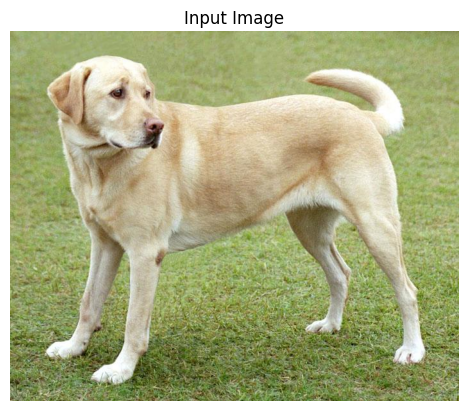

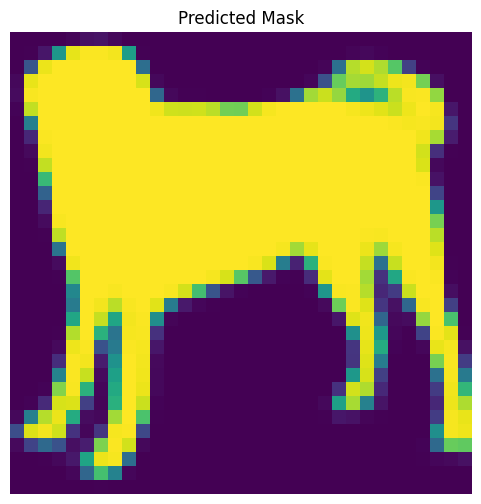

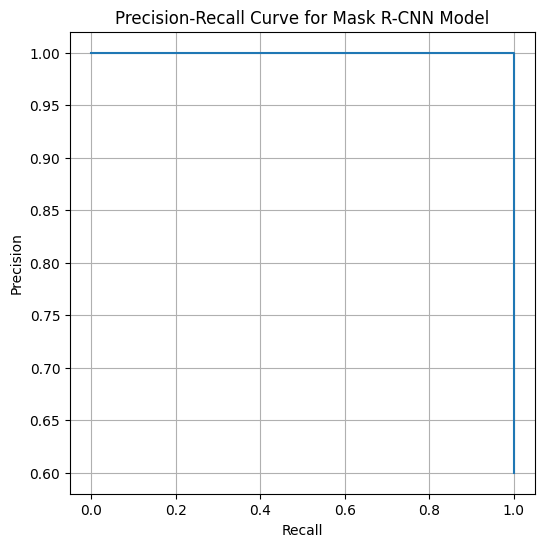

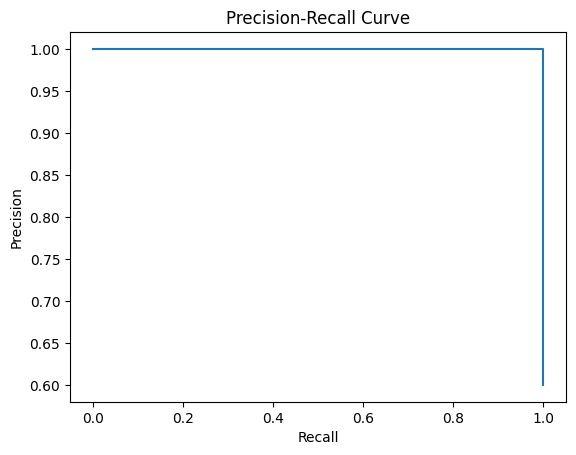

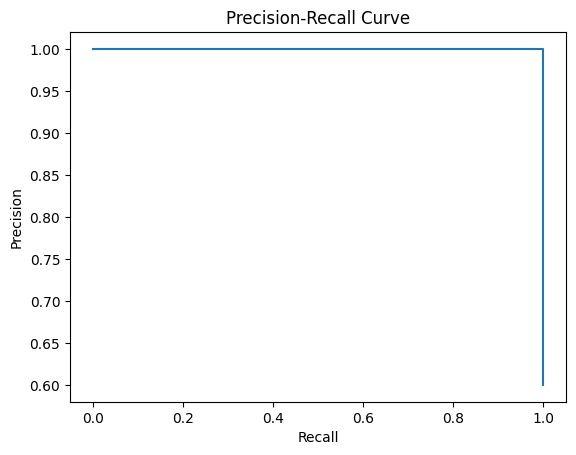

In [20]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve

# Ground truth labels (1 = object present, 0 = object absent)
y_true = [1,1,0,1,0,1,0,1,0,1]

# Model prediction scores
y_scores = [0.9,0.8,0.3,0.7,0.2,0.6,0.1,0.85,0.4,0.95]

# Calculate precision and recall
precision, recall, thresholds = precision_recall_curve(y_true, y_scores)

# Plot graph
plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

**Question 10:**

You are working with a city surveillance team to identify illegal parking
zones from street camera images. The model you built detects cars using bounding
boxes, but the team reports inaccurate overlaps with sidewalks and fails in complex
street scenes.
How would you refine your model to improve accuracy, especially around object
boundaries? What segmentation strategy and tools would you use?

**Improving Illegal Parking Detection Using Image Segmentation**

The current model detects cars using bounding boxes, which only provide a rectangular region around the object. This can cause inaccuracies in complex street scenes where vehicles overlap with sidewalks, roads, or other objects. Because bounding boxes cannot precisely represent object boundaries, the system may incorrectly identify cars as being parked illegally.

To improve accuracy, image segmentation techniques can be used instead of relying only on bounding boxes.

*Segmentation Strategy*

I would use Instance Segmentation, which identifies each object separately and generates a pixel-level mask around the object. This allows the system to accurately distinguish between cars, roads, sidewalks, and other elements in the scene.

A good approach is to use Mask R-CNN, which performs object detection and segmentation simultaneously. Unlike bounding boxes, it creates precise object masks, helping the model understand exact boundaries of vehicles.

*Steps to Improve the Model*

1. Use Instance Segmentation

* Replace or extend the current detection model with Mask R-CNN to generate pixel-level segmentation masks.

2. Dataset Annotation

* Annotate training images with segmentation masks for cars, sidewalks, and roads.

* Tools like LabelMe or CVAT can be used.

3. Improve Boundary Accuracy

* Train the model with high-resolution images and apply data augmentation (rotation, brightness, scaling) to handle complex scenes.

4. Semantic Segmentation for Road Understanding

* Use DeepLabV3+ to classify each pixel as road, sidewalk, or parking area.

5.Combine Detection with Scene Understanding

* First detect vehicles using Mask R-CNN.

* Then check whether the vehicle mask overlaps with the sidewalk segmentation region to identify illegal parking.

**Tools and Frameworks**

* Detectron2 – for implementing instance segmentation models

* TensorFlow Object Detection API – for training and evaluation

* OpenCV – for preprocessing and visualization

**Conclusion**

By using instance segmentation instead of simple bounding boxes, the model can accurately capture object boundaries and distinguish between cars, roads, and sidewalks. This significantly improves the detection of illegal parking in complex urban environments.